<a href="https://colab.research.google.com/github/taiwoas1/Rahman-Taiwo-Database-and-Analytics/blob/main/3_PYTHON_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/[USERNAME]/northstar-analytics-cw1/blob/main/notebooks/03_python_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 — Python Data Processing: Pandas, NumPy and Visualisation

Rahman Taiwo Aina-Saliu NorthStar Case Study — Database and Analytics

 NumPy vectorised statistics, Welch's t-test, and visualisations. Feature Engineering, removing anomaly

In [ ]:
!pip install seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
sns.set_style('whitegrid')

In [ ]:
# Load the datasets
customers  = pd.read_csv('customers.csv',  parse_dates=['signup_date'])
orders     = pd.read_csv('orders.csv',     parse_dates=['order_created_at'])
deliveries = pd.read_csv('deliveries.csv',
                         parse_dates=['dispatch_time','delivery_completed_at'])
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv',   parse_dates=['commission_date'])
hubs       = pd.read_csv('hubs.csv')
incidents  = pd.read_csv('incidents.csv',  parse_dates=['reported_at'])
complaints = pd.read_csv('complaints.csv', parse_dates=['created_at'])
app_events = pd.read_csv('app_events.csv', parse_dates=['event_timestamp'])

print('Loaded:')
for n, df in [('customers', customers), ('orders', orders),
              ('deliveries', deliveries), ('drivers', drivers),
              ('vehicles', vehicles), ('hubs', hubs),
              ('incidents', incidents), ('complaints', complaints),
              ('app_events', app_events)]:
    print(f'  {n:12s}: {df.shape}')

Loaded:
  customers   : (650, 9)
  orders      : (1250, 11)
  deliveries  : (950, 13)
  drivers     : (170, 8)
  vehicles    : (120, 8)
  hubs        : (8, 5)
  incidents   : (280, 7)
  complaints  : (320, 10)
  app_events  : (640, 10)


## 1. The zone normalisation

*



In [ ]:
def normalise_zone(s: pd.Series) -> pd.Series:
    mapping = {'ctr': 'Central', 'central': 'Central', 'airport': 'Airport',
               'north': 'North', 'south': 'South', 'east': 'East',
               'west': 'West', 'riverside': 'Riverside'}
    return s.str.strip().str.lower().map(lambda x: mapping.get(x, str(x).title()))

orders['pickup_zone']    = normalise_zone(orders['pickup_zone'])
orders['dropoff_zone']   = normalise_zone(orders['dropoff_zone'])
customers['home_zone']   = normalise_zone(customers['home_zone'])
drivers['base_zone']     = normalise_zone(drivers['base_zone'])
vehicles['assigned_zone']= normalise_zone(vehicles['assigned_zone'])
hubs['zone']             = normalise_zone(hubs['zone'])

print('Distinct zones:', sorted(orders['pickup_zone'].unique()))

Distinct zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


## 2. Feature engineering and anomaly removal

In [ ]:
deliveries['actual_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

anomalies = deliveries[deliveries['actual_duration_hrs'] < 0]
print(f'Anomalous duration records (completion before dispatch): {len(anomalies)}')
deliveries = deliveries[
    (deliveries['actual_duration_hrs'].isna()) |
    (deliveries['actual_duration_hrs'] >= 0)
].copy()

# Build the master dataframe
master = (orders
          .merge(deliveries, on='order_id', how='inner')
          .merge(drivers, on='driver_id', how='left')
          .merge(vehicles, on='vehicle_id', how='left')
          .merge(hubs, on='hub_id', how='left'))

master['within_window'] = (
    master['actual_duration_hrs'] <= master['promised_window_hours']
)
print(f'Master shape: {master.shape}')
print(f'Promise honour rate: {master["within_window"].mean()*100:.1f}%')

Anomalous duration records (completion before dispatch): 64
Master shape: (886, 43)
Promise honour rate: 48.8%


## 3. NumPy vectorised statistics and outlier detection

In [ ]:
metrics = {
    'order_value':    orders['order_value'].values,
    'route_distance': master['route_distance_km'].values,
    'fuel_cost':      master['fuel_or_charge_cost'].values,
    'overrides':      master['manual_route_override_count'].values
}
for name, arr in metrics.items():
    print(f'{name:>16s}: mean={np.mean(arr):7.2f}  std={np.std(arr):6.2f}  '
          f'median={np.median(arr):7.2f}  '
          f'IQR={np.percentile(arr,75) - np.percentile(arr,25):6.2f}')

     order_value: mean=  91.05  std= 60.89  median=  76.53  IQR= 73.18
  route_distance: mean=  13.93  std=  7.50  median=  12.77  IQR=  7.88
       fuel_cost: mean=  12.85  std=  4.38  median=  12.66  IQR=  5.93
       overrides: mean=   0.97  std=  1.10  median=   1.00  IQR=  2.00


In [ ]:
# Z-score outlier detection on the overriedes
override_arr = master['manual_route_override_count'].values
z = np.abs(stats.zscore(override_arr))
outliers = master[z > 2.5]
print(f'High-override outliers (|z|>2.5): {len(outliers)}')
print(outliers.groupby('hub_id').size().sort_values(ascending=False))

High-override outliers (|z|>2.5): 29
hub_id
H07    7
H01    4
H06    4
H08    4
H02    3
H03    3
H04    2
H05    2
dtype: int64


In [ ]:
#  EV vs Diesel failure rate: Welch's t-test
ev_fail = (master.loc[master['vehicle_type'] == 'EV', 'delivery_status'] == 'Failed').astype(int)
d_fail  = (master.loc[master['vehicle_type'] == 'Diesel', 'delivery_status'] == 'Failed').astype(int)
t_stat, p_val = stats.ttest_ind(ev_fail, d_fail, equal_var=False)
print(f'EV failure rate     : {ev_fail.mean()*100:.2f}%')
print(f'Diesel failure rate : {d_fail.mean()*100:.2f}%')
print(f'Welch t = {t_stat:.3f}, p = {p_val:.4f}')

EV failure rate     : 9.49%
Diesel failure rate : 19.26%
Welch t = -2.580, p = 0.0106


## 4. Profitablilty of service

In [ ]:
service_economics = master.groupby('service_type').agg(
    n_orders      = ('order_id', 'count'),
    total_revenue = ('order_value', 'sum'),
    avg_revenue   = ('order_value', 'mean'),
    total_fuel    = ('fuel_or_charge_cost', 'sum'),
    avg_rating    = ('customer_rating_post_delivery', 'mean'),
    failure_count = ('delivery_status', lambda s: (s == 'Failed').sum())
).round(2)

service_economics['gross_margin'] = (
    service_economics['total_revenue'] - service_economics['total_fuel']
).round(2)
service_economics['failure_pct'] = (
    100 * service_economics['failure_count'] / service_economics['n_orders']
).round(2)
service_economics['risk_tier'] = pd.cut(
    service_economics['failure_pct'],
    bins=[0, 10, 14, 100], labels=['Low', 'Medium', 'High']
)
service_economics.sort_values('failure_pct', ascending=False)

,n_orders,total_revenue,avg_revenue,total_fuel,avg_rating,failure_count,gross_margin,failure_pct,risk_tier
service_type,,,,,,,,,
Business,116,11256.47,97.04,1525.01,3.78,25,9731.46,21.55,High
Medical,99,8660.89,87.48,1274.48,3.80,16,7386.41,16.16,High
Passenger,242,23429.68,96.82,2972.70,3.84,38,20456.98,15.70,High
Retail,217,18703.64,86.19,2817.62,3.87,28,15886.02,12.90,Medium
Parcel,212,19170.39,90.43,2790.91,3.87,25,16379.48,11.79,Medium


## 5. Visualisation Data : Heatmap, Arrow Chart, Quadrant Chart

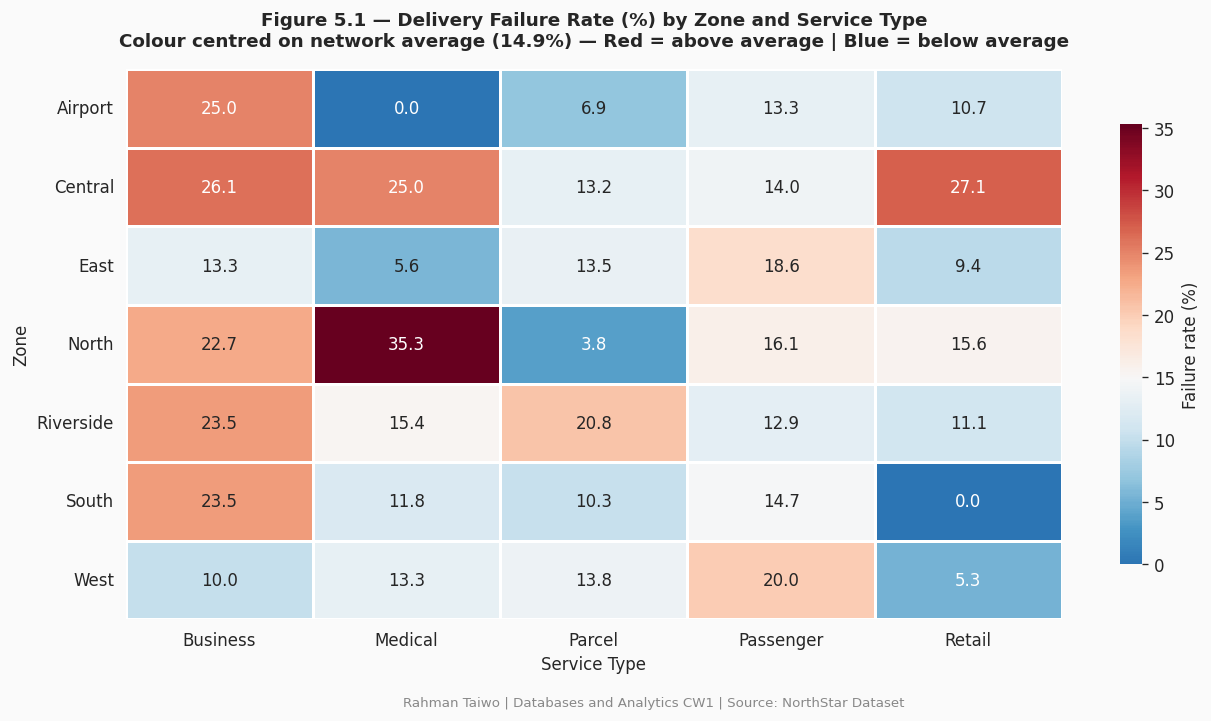

In [ ]:
import numpy as np

#  Heatmap : zone x service type: Figure 5.1
pivot = master.pivot_table(
    values='delivery_status',
    index='pickup_zone', columns='service_type',
    aggfunc=lambda s: 100 * (s == 'Failed').sum() / len(s)
).round(1)

avg_failure = pivot.values[~np.isnan(pivot.values)].mean()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAFA')

sns.heatmap(pivot,
            annot=True,
            fmt='.1f',
            cmap='RdBu_r',
            center=avg_failure,
            linewidths=0.8,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Failure rate (%)',
                      'shrink': 0.8})

ax.set_title('Figure 5.1 — Delivery Failure Rate (%) by Zone and Service Type\n'
             f'Colour centred on network average ({avg_failure:.1f}%) — '
             'Red = above average | Blue = below average',
             fontsize=11, fontweight='bold', pad=14)
ax.set_xlabel('Service Type', fontsize=10)
ax.set_ylabel('Zone', fontsize=10)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.figtext(0.5, 0.01,
            'Rahman Taiwo | Databases and Analytics CW1 | Source: NorthStar Dataset',
            ha='center', fontsize=8, color='#888888')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

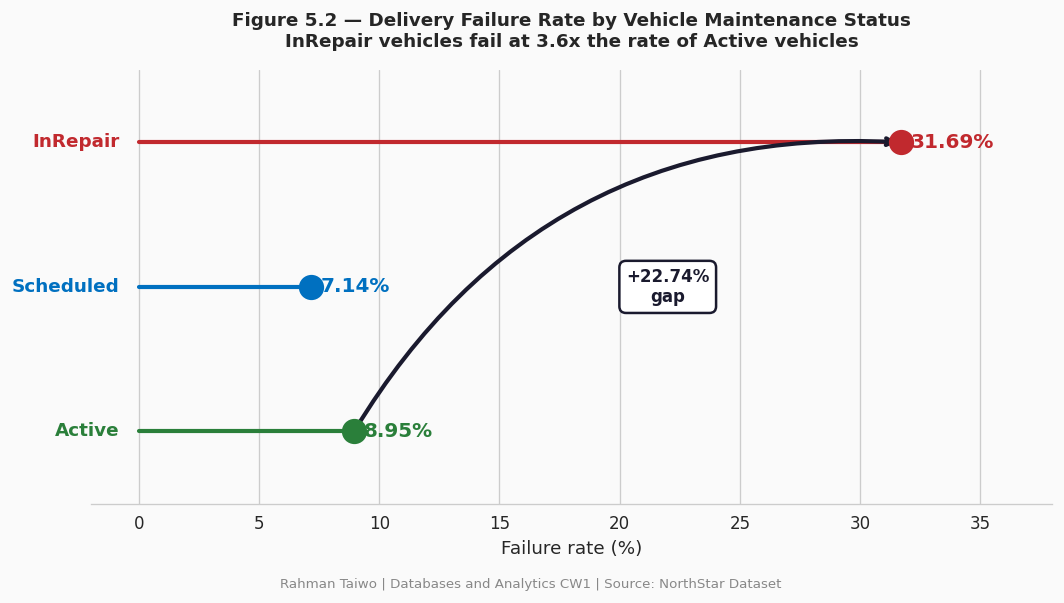

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Arrow chart for Figure 5.2 : Maintenance Status failure rate
maint = (master.groupby('maintenance_status')['delivery_status']
         .apply(lambda s: 100 * (s == 'Failed').mean()).round(2)
         .reset_index(name='failure_pct'))

maint = maint.sort_values('failure_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

colours = {'Active'   : '#2A7F3A',
           'Scheduled': '#0070C0',
           'InRepair' : '#C1292E'}

y_positions = {'Active': 0, 'Scheduled': 1, 'InRepair': 2}

for _, row in maint.iterrows():
    status = row['maintenance_status']
    pct    = row['failure_pct']
    ypos   = y_positions[status]
    col    = colours[status]

    ax.plot([0, pct], [ypos, ypos],
            color=col, linewidth=2.5, solid_capstyle='round')
    ax.scatter(pct, ypos, color=col, s=200, zorder=5)
    ax.text(pct + 0.4, ypos, str(pct) + '%',
            va='center', fontsize=12, fontweight='bold', color=col)
    ax.text(-0.8, ypos, status,
            va='center', ha='right', fontsize=11,
            color=col, fontweight='bold')


active_pct   = maint[maint['maintenance_status'] == 'Active']['failure_pct'].values[0]
inrepair_pct = maint[maint['maintenance_status'] == 'InRepair']['failure_pct'].values[0]
gap          = round(inrepair_pct - active_pct, 2)

ax.annotate('',
            xy=(inrepair_pct, 2), xytext=(active_pct, 0),
            arrowprops=dict(arrowstyle='->',
                            color='#1A1A2E',
                            lw=2.5,
                            connectionstyle='arc3,rad=-0.3'))

gap_label = '+' + str(gap) + '%\ngap'
ax.text(22, 1, gap_label,
        ha='center', va='center', fontsize=10,
        fontweight='bold', color='#1A1A2E',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#FFFFFF',
                  edgecolor='#1A1A2E',
                  linewidth=1.5))

ax.set_xlim(-2, 38)
ax.set_ylim(-0.5, 2.5)
ax.set_yticks([])
ax.set_xlabel('Failure rate (%)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_title('Figure 5.2 — Delivery Failure Rate by Vehicle Maintenance Status\n'
             'InRepair vehicles fail at 3.6x the rate of Active vehicles',
             fontsize=11, fontweight='bold', pad=14)

plt.figtext(0.5, 0.01,
            'Rahman Taiwo | Databases and Analytics CW1 | Source: NorthStar Dataset',
            ha='center', fontsize=8, color='#888888')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

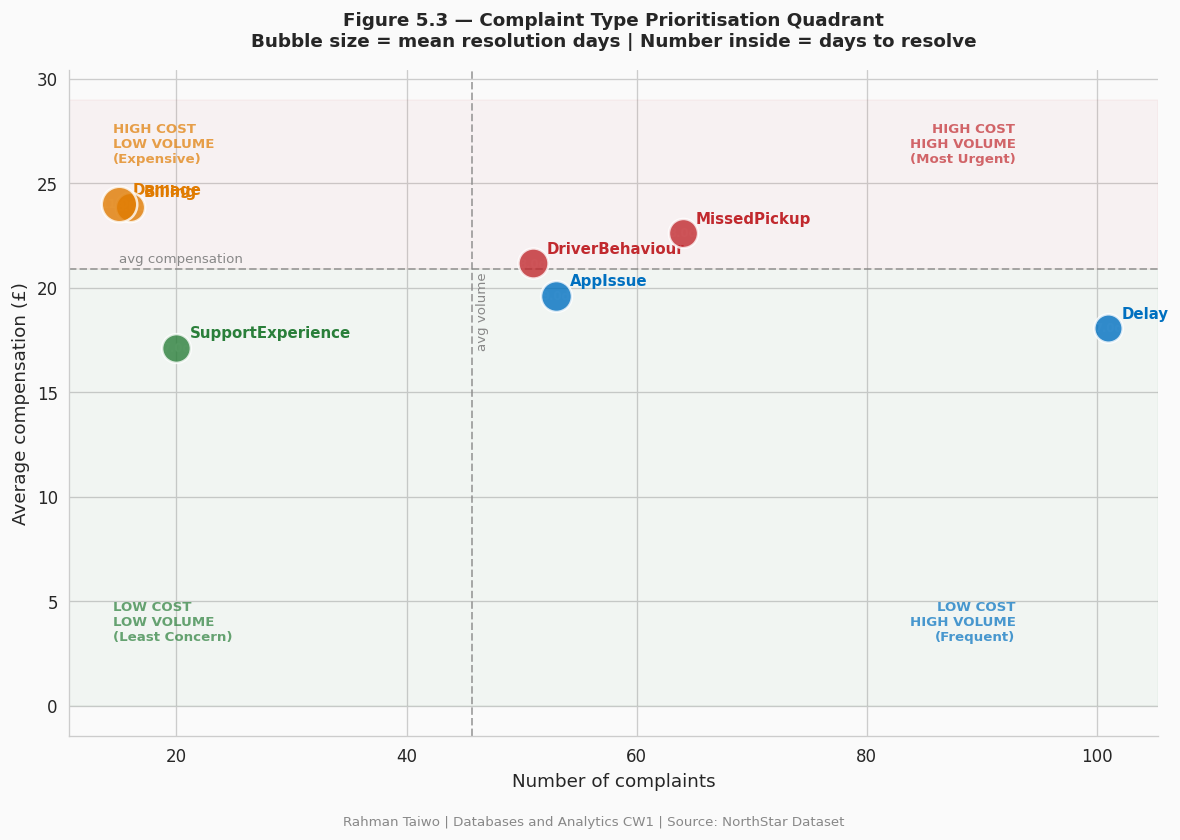

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

#  Quadrant chart Fuigure 5.3: volume and compensation
comp_summary = (complaints.groupby('complaint_type')
                .agg(n=('complaint_id', 'size'),
                     avg_comp=('compensation_amount', 'mean'),
                     avg_days=('resolution_days', 'mean'))
                .round(2).reset_index())


avg_n    = comp_summary['n'].mean()
avg_comp = comp_summary['avg_comp'].mean()

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.axvline(x=avg_n,    color='#888888', linewidth=1.2,
           linestyle='--', alpha=0.7)
ax.axhline(y=avg_comp, color='#888888', linewidth=1.2,
           linestyle='--', alpha=0.7)


ax.axhspan(avg_comp, comp_summary['avg_comp'].max() + 5,
           xmin=0, xmax=1, alpha=0.04, color='#C1292E')
ax.axhspan(0, avg_comp,
           xmin=0, xmax=1, alpha=0.04, color='#2A7F3A')


ax.text(comp_summary['n'].max() * 0.92,
        comp_summary['avg_comp'].max() + 2,
        'HIGH COST\nHIGH VOLUME\n(Most Urgent)',
        ha='right', fontsize=8, color='#C1292E',
        fontweight='bold', alpha=0.7)

ax.text(comp_summary['n'].min() - 0.5,
        comp_summary['avg_comp'].max() + 2,
        'HIGH COST\nLOW VOLUME\n(Expensive)',
        ha='left', fontsize=8, color='#E07B00',
        fontweight='bold', alpha=0.7)

ax.text(comp_summary['n'].max() * 0.92,
        avg_comp * 0.15,
        'LOW COST\nHIGH VOLUME\n(Frequent)',
        ha='right', fontsize=8, color='#0070C0',
        fontweight='bold', alpha=0.7)

ax.text(comp_summary['n'].min() - 0.5,
        avg_comp * 0.15,
        'LOW COST\nLOW VOLUME\n(Least Concern)',
        ha='left', fontsize=8, color='#2A7F3A',
        fontweight='bold', alpha=0.7)


for _, row in comp_summary.iterrows():
   t
    if row['n'] >= avg_n and row['avg_comp'] >= avg_comp:
        col = '#C1292E'
    elif row['n'] < avg_n and row['avg_comp'] >= avg_comp:
        col = '#E07B00'   e
    elif row['n'] >= avg_n and row['avg_comp'] < avg_comp:
        col = '#0070C0'
    else:
        col = '#2A7F3A'

    ax.scatter(row['n'], row['avg_comp'],
               s=row['avg_days'] * 40,
               color=col, alpha=0.8,
               edgecolor='white', linewidth=1.5,
               zorder=5)

    ax.annotate(row['complaint_type'],
                xy=(row['n'], row['avg_comp']),
                xytext=(8, 6),
                textcoords='offset points',
                fontsize=9, fontweight='bold',
                color=col)


    ax.text(row['n'], row['avg_comp'],
            str(round(row['avg_days'], 0)) + 'd',
            ha='center', va='center',
            fontsize=7, color='white', fontweight='bold')


ax.text(avg_n + 0.3, comp_summary['avg_comp'].min(),
        'avg volume', fontsize=8, color='#888888', rotation=90)
ax.text(comp_summary['n'].min(),
        avg_comp + 0.3,
        'avg compensation', fontsize=8, color='#888888')

ax.set_xlabel('Number of complaints', fontsize=11)
ax.set_ylabel('Average compensation (£)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Figure 5.3 — Complaint Type Prioritisation Quadrant\n'
             'Bubble size = mean resolution days | Number inside = days to resolve',
             fontsize=11, fontweight='bold', pad=14)

plt.figtext(0.5, 0.01,
            'Rahman Taiwo | Databases and Analytics CW1 | Source: NorthStar Dataset',
            ha='center', fontsize=8, color='#888888')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 6. Save cleaned master to processed data folder

The cleaned master frame is exported for use by the MongoDB notebook.

In [ ]:
import os
os.makedirs('processed', exist_ok=True)
master.to_csv('processed/master_clean.csv', index=False)
print(f'Master saved: {len(master)} rows × {master.shape[1]} columns')

Master saved: 886 rows × 43 columns
